In [18]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint

In [19]:
# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = var(r'κ') # k = sqrt(8πG)
V0 = var(r'V_0')
alp = var(r'α')
M = var('M')

# b) Define V function and its derivative
alp = 4
#M = 1.385e-20
V = function('V')(phi)
V = (M^(4+alp))/phi^alp
show(V)
dVdφ  = V.diff(phi)
show(dVdφ)

# V prime:
N = var('N')
Phi = function(r'Φ')(N)
dvdΦ = dVdφ.subs(phi == Phi)
show(dvdΦ)

M^8/φ^4

-4*M^8/φ^5

-4*M^8/Φ(N)^5

In [20]:
k =1
h = 0.7
ohm_m = 0.31
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
show(rho_c0)
M_val = (rho_c0*(8*pi)^(alp/2))^(1/(alp+4))*0.5
#show(M_val)
show(V.subs(M==M_val,phi==1))
gam = 1


1.12818740358662e-120

(2.82046850896656e-121)*pi^2

In [21]:
def solveSteinhardtKG(X,N):
    a = exp(N) # N = ln(a)
    rho_m = rho_c0*ohm_m*a^(-3)
    Vfunc = V.subs(M == M_val,phi ==X[0])
    #show(rho_m)
    dVfunc = dvdΦ.subs(M == M_val,Phi ==X[0])
    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])^2)
    #show(H2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2
    return [x1prime,x2prime,Vfunc]

In [22]:
dPhi = Phi.diff(N)
X = [Phi,dPhi]
show(solveSteinhardtKG([1,0],0))

[0,
 (1.12818740358662e-120)*pi^2/((9.40156169655520e-122)*pi^2 + 1.16579365037285e-121),
 (2.82046850896656e-121)*pi^2]

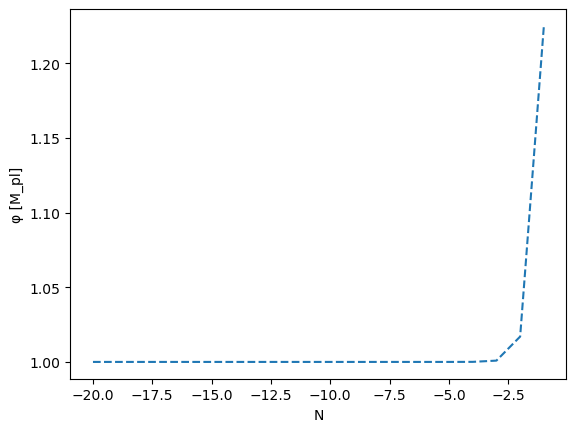

In [23]:
Nrange = np.arange(-20,0,1)
sol = odeint(solveSteinhardtKG,[1,0,rho_c0],t=Nrange)

# Plot of φ against redshift
phi_sol = sol[:,0]
phi_prime = sol[:,1]
Vnumber = sol[:,2]
#show(Vnumber)
z_values = exp(-Nrange)
plt.xlabel("N")
plt.ylabel(r"φ [M_pl]")
plt.plot(Nrange,phi_sol,'--')

In [24]:
# Multiple Values of Q
def other_parameters(fi,dfi,V,N):
    a = exp(N) # N = ln(a)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*a^(-3)
    H2 = (rho_m + V)/(3-0.5*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + V #Energy density of φ (ρ_φ)
    O_φ = k^2/3*rho_φ/H2 # Ωφ
    Pφ = 0.5*(dfi^2*H2) - V
    w = Pφ/rho_φ #Equation of State wΦ
    Y_φ = (Pφ+rho_φ)/rho_φ
    #show(Y_φ)
    return z,rho_φ,Pφ,O_φ,w,Y_φ,rho_m

In [25]:
z,rho,P,om,w,Y_φ,rho_mat= other_parameters(phi_sol,phi_prime,Vnumber,Nrange)
show(rho)
Z = z+1

array([1.12818740e-120, 3.91187824e-120, 6.69556909e-120, 9.47925993e-120,
       1.22629508e-119, 1.50466416e-119, 1.78303324e-119, 2.06140233e-119,
       2.33977141e-119, 2.61814050e-119, 2.89650958e-119, 3.17487867e-119,
       3.45324775e-119, 3.73161683e-119, 4.00998587e-119, 4.28835414e-119,
       4.56670774e-119, 4.84476925e-119, 5.11719359e-119, 5.32280450e-119])

array([1.12818740e-120, 3.91187824e-120, 6.69556909e-120, 9.47925993e-120,
       1.22629508e-119, 1.50466416e-119, 1.78303324e-119, 2.06140233e-119,
       2.33977141e-119, 2.61814050e-119, 2.89650958e-119, 3.17487867e-119,
       3.45324775e-119, 3.73161683e-119, 4.00998591e-119, 4.28835495e-119,
       4.56672389e-119, 4.84509664e-119, 5.12497278e-119, 5.54623554e-119])

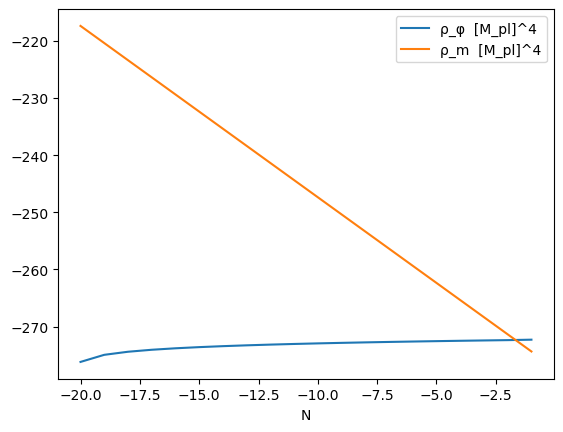

In [28]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N

#plt.plot(Nrange,phi_sol, label  =r"φ [M_pl]")
#plt.plot(Nrange,phi_prime, label  =r"φ' [M_pl]")
plt.plot(Nrange,log(rho),label=r"ρ_φ  [M_pl]^4")
plt.plot(Nrange,log(rho_mat),label=r"ρ_m  [M_pl]^4")
#plt.plot(Nrange,P,label=r"P_φ  [M_pl]^4") 
#plt.plot(Nrange,om,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
#plt.plot(Nrange,Y_φ,label=r"Y_φ")
plt.xlabel("N")
plt.legend()

### Oberservations:
Parameters experience a change of shape at N = 0. This is current day. \
$P_φ$ is zero for all N. This makes sense as $P_φ = (γ-1)ρ_φ$ and we have set $γ$ to 1. \
$ρ_φ$ is steadily increases from zero at a constant rate for N less than zero before it has a small rapid expansion at N = 0 before it plateaus. \


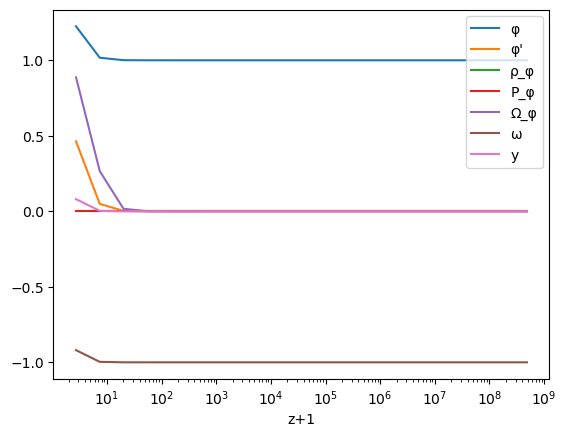

In [10]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1
plt.plot(Z,phi_sol, label  =r"φ")
plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,rho,label=r"ρ_φ")
plt.plot(Z,P,label=r"P_φ") 
plt.plot(Z,om,label=r"Ω_φ") # something wrong as it shouldn't be zero
plt.plot(Z,w,label=r"ω") # interestingly -1 for all z except at current value
plt.plot(Z,Y_φ,label=r"y")
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

### Plotting ωφ,ρφ,Ωφ,Pφ values for different initial Q values

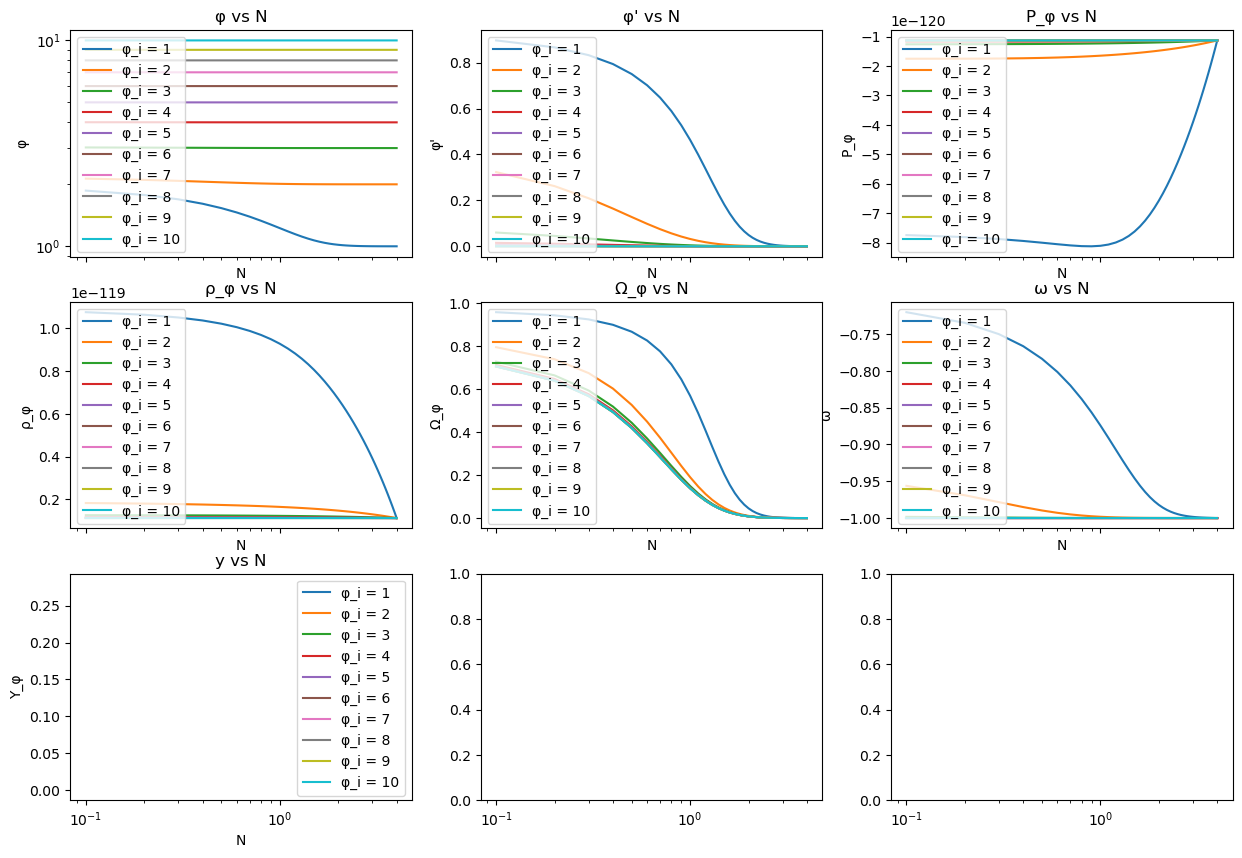

In [11]:
# Test for Attacting Q values
Nrange = np.arange(-4,0,.1)
z_list = []
rho_list = []
P_list = []
om_list = []
w_list = []

fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)

for i in range(1,11,1):
    solQ = odeint(solveSteinhardtKG,[i,0,rho_c0],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,om,w,Y_φ = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
    z_list.append(z);rho_list.append(rho);P_list.append(P);om_list.append(om);w_list.append(w)

    # Use Subplots to observe each parameter over all N for a different intial value of φ
    axs[0,0].plot(-Nrange,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "N",title=r"φ vs N")
    axs[0,0].legend()

    axs[0,1].plot(-Nrange,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "N",title=r"φ' vs N")
    axs[0,1].legend()

    axs[0,2].plot(-Nrange,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "N",title=r"P_φ vs N")
    axs[0,2].legend()

    axs[1,0].plot(-Nrange,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "N",title=r"ρ_φ vs N")
    axs[1,0].legend()

    axs[1,1].plot(-Nrange,om,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "N",title=r"Ω_φ vs N")
    axs[1,1].legend()

    axs[1,2].plot(-Nrange,w,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"ω", xlabel = "N",title=r"ω vs N")
    axs[1,2].legend()

    axs[2,0].plot(Nrange,Y_φ,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"Y_φ", xlabel = "N",title=r"y vs N")
    axs[2,0].legend()
    

axs[0,0].set_xscale('log')
axs[0,0].set_yscale('log')

#def multipleQ(Q,N):
#axs[0,0].ylabel()
    #axs[0,0].xlabel()    
    

### Improvement to code above:
The code below is the same as the code above, but now allows you to easily choose what is plotted on the x-axis. Also changed the range of N values to include Negative values as well. 

array([1.12818740e-120, 5.58203441e-120, 1.00355132e-119, 1.44881824e-119,
       1.89394914e-119, 2.33887339e-119, 2.78349920e-119, 3.22770578e-119,
       3.67133308e-119, 4.11416828e-119, 4.55592813e-119, 4.99623569e-119,
       5.43459063e-119, 5.87033134e-119, 6.30258821e-119, 6.73022817e-119,
       7.15179161e-119, 7.56542771e-119, 7.96883833e-119, 8.35924851e-119,
       8.73342980e-119, 9.08780740e-119, 9.41867798e-119, 9.72254329e-119,
       9.99652437e-119, 1.02387723e-118, 1.04487611e-118, 1.06273687e-118,
       1.07767142e-118, 1.08998112e-118, 1.10001441e-118, 1.10812772e-118,
       1.11465669e-118, 1.11989912e-118, 1.12410825e-118, 1.12749297e-118,
       1.13022202e-118, 1.13242987e-118, 1.13422281e-118, 1.13568451e-118,
       1.13688077e-118, 1.13786341e-118, 1.13867338e-118, 1.13934316e-118,
       1.13989863e-118, 1.14036056e-118, 1.14074563e-118, 1.14106739e-118,
       1.14133685e-118, 1.14156298e-118, 1.14175316e-118, 1.14191345e-118,
       1.14204887e-118, 1.14216354e-118, 1.14226089e-118, 1.14234376e-118,
       1.14241450e-118, 1.14247508e-118, 1.14252712e-118, 1.14257198e-118,
       1.14261079e-118, 1.14264449e-118, 1.14267387e-118, 1.14269958e-118,
       1.14272217e-118, 1.14274211e-118, 1.14275977e-118, 1.14277548e-118,
       1.14278952e-118, 1.14280211e-118, 1.14281344e-118, 1.14282369e-118,
       1.14283298e-118, 1.14284145e-118, 1.14284919e-118, 1.14285628e-118,
       1.14286281e-118, 1.14286883e-118, 1.14287440e-118, 1.14287957e-118,
       1.14288438e-118, 1.14288887e-118, 1.14289307e-118, 1.14289700e-118,
       1.14290069e-118, 1.14290416e-118, 1.14290743e-118, 1.14291052e-118,
       1.14291345e-118, 1.14291621e-118, 1.14291884e-118, 1.14292134e-118,
       1.14292371e-118, 1.14292597e-118, 1.14292813e-118, 1.14293019e-118,
       1.14293216e-118, 1.14293405e-118, 1.14293585e-118, 1.14293758e-118])

array([1.12818740e-120, 3.27608728e-120, 5.42392809e-120, 7.57163782e-120,
       9.71912775e-120, 1.18662837e-119, 1.40129565e-119, 1.61589503e-119,
       1.83040044e-119, 2.04477711e-119, 2.25897845e-119, 2.47294213e-119,
       2.68658457e-119, 2.89979388e-119, 3.11242046e-119, 3.32426492e-119,
       3.53506245e-119, 3.74446326e-119, 3.95200871e-119, 4.15710333e-119,
       4.35898403e-119, 4.55669015e-119, 4.74904029e-119, 4.93462613e-119,
       5.11183682e-119, 5.27892844e-119, 5.43414850e-119, 5.57591130e-119,
       5.70299900e-119, 5.81474127e-119, 5.91112077e-119, 5.99276891e-119,
       6.06085397e-119, 6.11689912e-119, 6.16258456e-119, 6.19957873e-119,
       6.22942179e-119, 6.25346298e-119, 6.27284059e-119, 6.28848982e-119,
       6.30116515e-119, 6.31146821e-119, 6.31987552e-119, 6.32676333e-119,
       6.33242866e-119, 6.33710637e-119, 6.34098278e-119, 6.34420626e-119,
       6.34689554e-119, 6.34914611e-119, 6.35103512e-119, 6.35262522e-119,
       6.35396750e-119, 6.35510379e-119, 6.35606845e-119, 6.35688982e-119,
       6.35759132e-119, 6.35819232e-119, 6.35870894e-119, 6.35915455e-119,
       6.35954028e-119, 6.35987542e-119, 6.36016772e-119, 6.36042366e-119,
       6.36064866e-119, 6.36084727e-119, 6.36102329e-119, 6.36117993e-119,
       6.36131989e-119, 6.36144545e-119, 6.36155854e-119, 6.36166078e-119,
       6.36175356e-119, 6.36183807e-119, 6.36191530e-119, 6.36198613e-119,
       6.36205129e-119, 6.36211141e-119, 6.36216706e-119, 6.36221869e-119,
       6.36226674e-119, 6.36231156e-119, 6.36235346e-119, 6.36239272e-119,
       6.36242958e-119, 6.36246427e-119, 6.36249697e-119, 6.36252784e-119,
       6.36255704e-119, 6.36258471e-119, 6.36261095e-119, 6.36263589e-119,
       6.36265962e-119, 6.36268222e-119, 6.36270378e-119, 6.36272437e-119,
       6.36274405e-119, 6.36276288e-119, 6.36278092e-119, 6.36279821e-119])

array([1.12818740e-120, 2.28757335e-120, 3.44694674e-120, 4.60629200e-120,
       5.76559015e-120, 6.92481683e-120, 8.08394006e-120, 9.24291772e-120,
       1.04016939e-119, 1.15601939e-119, 1.27183175e-119, 1.38759303e-119,
       1.50328514e-119, 1.61888379e-119, 1.73435634e-119, 1.84965897e-119,
       1.96473289e-119, 2.07949952e-119, 2.19385400e-119, 2.30765697e-119,
       2.42072434e-119, 2.53281457e-119, 2.64361387e-119, 2.75271993e-119,
       2.85962575e-119, 2.96370710e-119, 3.06421860e-119, 3.16030563e-119,
       3.25103984e-119, 3.33548350e-119, 3.41278103e-119, 3.48226502e-119,
       3.54355240e-119, 3.59660304e-119, 3.64172173e-119, 3.67950308e-119,
       3.71073832e-119, 3.73631159e-119, 3.75710982e-119, 3.77395892e-119,
       3.78758810e-119, 3.79861702e-119, 3.80755809e-119, 3.81482719e-119,
       3.82075775e-119, 3.82561517e-119, 3.82960989e-119, 3.83290870e-119,
       3.83564392e-119, 3.83792082e-119, 3.83982344e-119, 3.84141920e-119,
       3.84276237e-119, 3.84389688e-119, 3.84485845e-119, 3.84567623e-119,
       3.84637411e-119, 3.84697175e-119, 3.84748535e-119, 3.84792833e-119,
       3.84831182e-119, 3.84864508e-119, 3.84893580e-119, 3.84919043e-119,
       3.84941434e-119, 3.84961204e-119, 3.84978730e-119, 3.84994331e-119,
       3.85008275e-119, 3.85020786e-119, 3.85032057e-119, 3.85042250e-119,
       3.85051501e-119, 3.85059928e-119, 3.85067631e-119, 3.85074696e-119,
       3.85081196e-119, 3.85087195e-119, 3.85092748e-119, 3.85097901e-119,
       3.85102696e-119, 3.85107169e-119, 3.85111352e-119, 3.85115271e-119,
       3.85118952e-119, 3.85122415e-119, 3.85125679e-119, 3.85128762e-119,
       3.85131678e-119, 3.85134440e-119, 3.85137061e-119, 3.85139552e-119,
       3.85141921e-119, 3.85144179e-119, 3.85146332e-119, 3.85148388e-119,
       3.85150354e-119, 3.85152235e-119, 3.85154036e-119, 3.85155764e-119])

array([1.12818740e-120, 1.80779889e-120, 2.48740696e-120, 3.16700770e-120,
       3.84659601e-120, 4.52616552e-120, 5.20570783e-120, 5.88521181e-120,
       6.56466275e-120, 7.24404097e-120, 7.92332004e-120, 8.60246451e-120,
       9.28142664e-120, 9.96014218e-120, 1.06385246e-119, 1.13164576e-119,
       1.19937843e-119, 1.26702943e-119, 1.33457050e-119, 1.40196376e-119,
       1.46915858e-119, 1.53608752e-119, 1.60266111e-119, 1.66876145e-119,
       1.73423436e-119, 1.79888044e-119, 1.86244556e-119, 1.92461200e-119,
       1.98499263e-119, 2.04313151e-119, 2.09851520e-119, 2.15059905e-119,
       2.19885019e-119, 2.24280424e-119, 2.28212566e-119, 2.31665672e-119,
       2.34644031e-119, 2.37170916e-119, 2.39284576e-119, 2.41032588e-119,
       2.42466126e-119, 2.43635307e-119, 2.44586081e-119, 2.45358642e-119,
       2.45986969e-119, 2.46499113e-119, 2.46917848e-119, 2.47261476e-119,
       2.47544610e-119, 2.47778887e-119, 2.47973570e-119, 2.48136040e-119,
       2.48272199e-119, 2.48386779e-119, 2.48483590e-119, 2.48565715e-119,
       2.48635655e-119, 2.48695452e-119, 2.48746778e-119, 2.48791005e-119,
       2.48829268e-119, 2.48862503e-119, 2.48891487e-119, 2.48916868e-119,
       2.48939186e-119, 2.48958890e-119, 2.48976359e-119, 2.48991911e-119,
       2.49005811e-119, 2.49018285e-119, 2.49029524e-119, 2.49039688e-119,
       2.49048914e-119, 2.49057320e-119, 2.49065005e-119, 2.49072053e-119,
       2.49078539e-119, 2.49084525e-119, 2.49090067e-119, 2.49095210e-119,
       2.49099996e-119, 2.49104461e-119, 2.49108636e-119, 2.49112549e-119,
       2.49116223e-119, 2.49119681e-119, 2.49122940e-119, 2.49126018e-119,
       2.49128930e-119, 2.49131689e-119, 2.49134306e-119, 2.49136793e-119,
       2.49139160e-119, 2.49141415e-119, 2.49143565e-119, 2.49145619e-119,
       2.49147582e-119, 2.49149461e-119, 2.49151261e-119, 2.49152986e-119])

array([1.12818740e-120, 1.55246565e-120, 1.97674287e-120, 2.40101784e-120,
       2.82528897e-120, 3.24955429e-120, 3.67381121e-120, 4.09805632e-120,
       4.52228509e-120, 4.94649143e-120, 5.37066722e-120, 5.79480151e-120,
       6.21887958e-120, 6.64288167e-120, 7.06678098e-120, 7.49054153e-120,
       7.91411484e-120, 8.33743560e-120, 8.76041584e-120, 9.18293733e-120,
       9.60484123e-120, 1.00259146e-119, 1.04458724e-119, 1.08643347e-119,
       1.12807967e-119, 1.16945916e-119, 1.21048453e-119, 1.25104233e-119,
       1.29098723e-119, 1.33013640e-119, 1.36826512e-119, 1.40510566e-119,
       1.44035186e-119, 1.47367210e-119, 1.50473236e-119, 1.53322850e-119,
       1.55892314e-119, 1.58167871e-119, 1.60147712e-119, 1.61842022e-119,
       1.63271091e-119, 1.64462161e-119, 1.65445916e-119, 1.66253396e-119,
       1.66913783e-119, 1.67453115e-119, 1.67893756e-119, 1.68254411e-119,
       1.68550430e-119, 1.68794254e-119, 1.68995889e-119, 1.69163347e-119,
       1.69303037e-119, 1.69420085e-119, 1.69518600e-119, 1.69601885e-119,
       1.69672605e-119, 1.69732918e-119, 1.69784577e-119, 1.69829016e-119,
       1.69867407e-119, 1.69900716e-119, 1.69929739e-119, 1.69955136e-119,
       1.69977455e-119, 1.69997153e-119, 1.70014612e-119, 1.70030150e-119,
       1.70044036e-119, 1.70056497e-119, 1.70067722e-119, 1.70077874e-119,
       1.70087089e-119, 1.70095485e-119, 1.70103160e-119, 1.70110200e-119,
       1.70116678e-119, 1.70122658e-119, 1.70128193e-119, 1.70133330e-119,
       1.70138112e-119, 1.70142572e-119, 1.70146743e-119, 1.70150652e-119,
       1.70154323e-119, 1.70157778e-119, 1.70161034e-119, 1.70164110e-119,
       1.70167019e-119, 1.70169775e-119, 1.70172391e-119, 1.70174876e-119,
       1.70177241e-119, 1.70179494e-119, 1.70181643e-119, 1.70183696e-119,
       1.70185657e-119, 1.70187535e-119, 1.70189334e-119, 1.70191058e-119])

array([1.12818740e-120, 1.40655642e-120, 1.68492506e-120, 1.96329294e-120,
       2.24165947e-120, 2.52002397e-120, 2.79838554e-120, 3.07674299e-120,
       3.35509474e-120, 3.63343866e-120, 3.91177193e-120, 4.19009071e-120,
       4.46838988e-120, 4.74666255e-120, 5.02489934e-120, 5.30308771e-120,
       5.58121067e-120, 5.85924541e-120, 6.13716110e-120, 6.41491624e-120,
       6.69245499e-120, 6.96970222e-120, 7.24655699e-120, 7.52288397e-120,
       7.79850207e-120, 8.07316971e-120, 8.34656595e-120, 8.61826675e-120,
       8.88771596e-120, 9.15419133e-120, 9.41676716e-120, 9.67427750e-120,
       9.92528741e-120, 1.01680840e-119, 1.04007032e-119, 1.06210090e-119,
       1.08268370e-119, 1.10161974e-119, 1.11875095e-119, 1.13398151e-119,
       1.14729123e-119, 1.15873681e-119, 1.16844096e-119, 1.17657309e-119,
       1.18332720e-119, 1.18890212e-119, 1.19348679e-119, 1.19725145e-119,
       1.20034364e-119, 1.20288775e-119, 1.20498665e-119, 1.20672428e-119,
       1.20816857e-119, 1.20937425e-119, 1.21038529e-119, 1.21123704e-119,
       1.21195796e-119, 1.21257100e-119, 1.21309473e-119, 1.21354424e-119,
       1.21393183e-119, 1.21426755e-119, 1.21455968e-119, 1.21481501e-119,
       1.21503918e-119, 1.21523687e-119, 1.21541197e-119, 1.21556773e-119,
       1.21570687e-119, 1.21583168e-119, 1.21594408e-119, 1.21604572e-119,
       1.21613796e-119, 1.21622198e-119, 1.21629879e-119, 1.21636923e-119,
       1.21643405e-119, 1.21649387e-119, 1.21654925e-119, 1.21660064e-119,
       1.21664847e-119, 1.21669309e-119, 1.21673481e-119, 1.21677391e-119,
       1.21681063e-119, 1.21684518e-119, 1.21687776e-119, 1.21690852e-119,
       1.21693762e-119, 1.21696519e-119, 1.21699135e-119, 1.21701621e-119,
       1.21703986e-119, 1.21706239e-119, 1.21708389e-119, 1.21710441e-119,
       1.21712404e-119, 1.21714282e-119, 1.21716081e-119, 1.21717806e-119])

array([1.12818740e-120, 1.31831720e-120, 1.50844687e-120, 1.69857622e-120,
       1.88870507e-120, 2.07883313e-120, 2.26896005e-120, 2.45908539e-120,
       2.64920853e-120, 2.83932864e-120, 3.02944465e-120, 3.21955507e-120,
       3.40965792e-120, 3.59975053e-120, 3.78982931e-120, 3.97988940e-120,
       4.16992426e-120, 4.35992507e-120, 4.54987991e-120, 4.73977274e-120,
       4.92958194e-120, 5.11927837e-120, 5.30882280e-120, 5.49816251e-120,
       5.68722667e-120, 5.87592031e-120, 6.06411645e-120, 6.25164576e-120,
       6.43828348e-120, 6.62373295e-120, 6.80760564e-120, 6.98939793e-120,
       7.16846586e-120, 7.34400097e-120, 7.51501243e-120, 7.68032381e-120,
       7.83859532e-120, 7.98838244e-120, 8.12823743e-120, 8.25684843e-120,
       8.37319488e-120, 8.47668368e-120, 8.56722795e-120, 8.64524547e-120,
       8.71157953e-120, 8.76736920e-120, 8.81390572e-120, 8.85250592e-120,
       8.88441961e-120, 8.91077375e-120, 8.93254773e-120, 8.95057040e-120,
       8.96553030e-120, 8.97799215e-120, 8.98841540e-120, 8.99717206e-120,
       9.00456269e-120, 9.01083012e-120, 9.01617069e-120, 9.02074352e-120,
       9.02467795e-120, 9.02807940e-120, 9.03103414e-120, 9.03361297e-120,
       9.03587425e-120, 9.03786624e-120, 9.03962895e-120, 9.04119574e-120,
       9.04259443e-120, 9.04384836e-120, 9.04497714e-120, 9.04599733e-120,
       9.04692292e-120, 9.04776580e-120, 9.04853609e-120, 9.04924242e-120,
       9.04989222e-120, 9.05049184e-120, 9.05104678e-120, 9.05156180e-120,
       9.05204103e-120, 9.05248806e-120, 9.05290604e-120, 9.05329772e-120,
       9.05366553e-120, 9.05401160e-120, 9.05433783e-120, 9.05464591e-120,
       9.05493732e-120, 9.05521341e-120, 9.05547537e-120, 9.05572428e-120,
       9.05596111e-120, 9.05618673e-120, 9.05640194e-120, 9.05660744e-120,
       9.05680389e-120, 9.05699190e-120, 9.05717199e-120, 9.05734467e-120])

array([1.12818740e-120, 1.26243174e-120, 1.39667602e-120, 1.53092016e-120,
       1.66516410e-120, 1.79940771e-120, 1.93365084e-120, 2.06789330e-120,
       2.20213485e-120, 2.33637512e-120, 2.47061367e-120, 2.60484988e-120,
       2.73908292e-120, 2.87331167e-120, 3.00753462e-120, 3.14174973e-120,
       3.27595428e-120, 3.41014455e-120, 3.54431555e-120, 3.67846055e-120,
       3.81257046e-120, 3.94663306e-120, 4.08063182e-120, 4.21454454e-120,
       4.34834133e-120, 4.48198198e-120, 4.61541255e-120, 4.74856077e-120,
       4.88133007e-120, 5.01359184e-120, 5.14517571e-120, 5.27585728e-120,
       5.40534358e-120, 5.53325642e-120, 5.65911485e-120, 5.78231934e-120,
       5.90214195e-120, 6.01772876e-120, 6.12812228e-120, 6.23231084e-120,
       6.32930689e-120, 6.41824769e-120, 6.49850015e-120, 6.56974416e-120,
       6.63201101e-120, 6.68566622e-120, 6.73134448e-120, 6.76985749e-120,
       6.80209882e-120, 6.82896407e-120, 6.85129455e-120, 6.86984484e-120,
       6.88526945e-120, 6.89812259e-120, 6.90886576e-120, 6.91787885e-120,
       6.92547229e-120, 6.93189868e-120, 6.93736316e-120, 6.94203231e-120,
       6.94604155e-120, 6.94950118e-120, 6.95250128e-120, 6.95511563e-120,
       6.95740487e-120, 6.95941898e-120, 6.96119935e-120, 6.96278030e-120,
       6.96419047e-120, 6.96545377e-120, 6.96659028e-120, 6.96761689e-120,
       6.96854786e-120, 6.96939528e-120, 6.97016944e-120, 6.97087910e-120,
       6.97153177e-120, 6.97213390e-120, 6.97269103e-120, 6.97320799e-120,
       6.97368894e-120, 6.97413750e-120, 6.97455685e-120, 6.97494976e-120,
       6.97531868e-120, 6.97566577e-120, 6.97599292e-120, 6.97630184e-120,
       6.97659403e-120, 6.97687082e-120, 6.97713344e-120, 6.97738295e-120,
       6.97762034e-120, 6.97784648e-120, 6.97806216e-120, 6.97826811e-120,
       6.97846499e-120, 6.97865338e-120, 6.97883384e-120, 6.97900687e-120])

array([1.12818740e-120, 1.22565215e-120, 1.32311687e-120, 1.42058153e-120,
       1.51804610e-120, 1.61551052e-120, 1.71297473e-120, 1.81043863e-120,
       1.90790212e-120, 2.00536504e-120, 2.10282719e-120, 2.20028828e-120,
       2.29774795e-120, 2.39520568e-120, 2.49266082e-120, 2.59011243e-120,
       2.68755929e-120, 2.78499974e-120, 2.88243153e-120, 2.97985164e-120,
       3.07725597e-120, 3.17463902e-120, 3.27199338e-120, 3.36930901e-120,
       3.46657244e-120, 3.56376551e-120, 3.66086380e-120, 3.75783449e-120,
       3.85463359e-120, 3.95120220e-120, 4.04746178e-120, 4.14330795e-120,
       4.23860276e-120, 4.33316527e-120, 4.42676039e-120, 4.51908661e-120,
       4.60976386e-120, 4.69832373e-120, 4.78420587e-120, 4.86676552e-120,
       4.94529750e-120, 5.01908040e-120, 5.08743980e-120, 5.14982214e-120,
       5.20586359e-120, 5.25543604e-120, 5.29865733e-120, 5.33586393e-120,
       5.36755621e-120, 5.39433225e-120, 5.41682538e-120, 5.43565511e-120,
       5.45139460e-120, 5.46455328e-120, 5.47557105e-120, 5.48481993e-120,
       5.49261004e-120, 5.49919737e-120, 5.50479192e-120, 5.50956538e-120,
       5.51365792e-120, 5.51718394e-120, 5.52023699e-120, 5.52289365e-120,
       5.52521681e-120, 5.52725825e-120, 5.52906075e-120, 5.53065974e-120,
       5.53208471e-120, 5.53336024e-120, 5.53450693e-120, 5.53554207e-120,
       5.53648025e-120, 5.53733381e-120, 5.53811323e-120, 5.53882743e-120,
       5.53948404e-120, 5.54008961e-120, 5.54064977e-120, 5.54116941e-120,
       5.54165273e-120, 5.54210342e-120, 5.54252467e-120, 5.54291930e-120,
       5.54328978e-120, 5.54363827e-120, 5.54396671e-120, 5.54427680e-120,
       5.54457006e-120, 5.54484785e-120, 5.54511137e-120, 5.54536173e-120,
       5.54559989e-120, 5.54582675e-120, 5.54604311e-120, 5.54624968e-120,
       5.54644714e-120, 5.54663608e-120, 5.54681705e-120, 5.54699055e-120])

array([1.12818740e-120, 1.20064916e-120, 1.27311090e-120, 1.34557261e-120,
       1.41803427e-120, 1.49049587e-120, 1.56295737e-120, 1.63541872e-120,
       1.70787987e-120, 1.78034075e-120, 1.85280126e-120, 1.92526127e-120,
       1.99772060e-120, 2.07017901e-120, 2.14263617e-120, 2.21509166e-120,
       2.28754488e-120, 2.35999505e-120, 2.43244108e-120, 2.50488154e-120,
       2.57731448e-120, 2.64973728e-120, 2.72214638e-120, 2.79453700e-120,
       2.86690272e-120, 2.93923483e-120, 3.01152164e-120, 3.08374742e-120,
       3.15589102e-120, 3.22792404e-120, 3.29980847e-120, 3.37149350e-120,
       3.44291151e-120, 3.51397296e-120, 3.58455996e-120, 3.65451873e-120,
       3.72365093e-120, 3.79170461e-120, 3.85836617e-120, 3.92325548e-120,
       3.98592743e-120, 4.04588385e-120, 4.10259908e-120, 4.15555999e-120,
       4.20431683e-120, 4.24853564e-120, 4.28803963e-120, 4.32282845e-120,
       4.35307043e-120, 4.37907151e-120, 4.40123099e-120, 4.41999515e-120,
       4.43581760e-120, 4.44913048e-120, 4.46032685e-120, 4.46975250e-120,
       4.47770438e-120, 4.48443317e-120, 4.49014796e-120, 4.49502175e-120,
       4.49919705e-120, 4.50279087e-120, 4.50589924e-120, 4.50860102e-120,
       4.51096099e-120, 4.51303255e-120, 4.51485977e-120, 4.51647915e-120,
       4.51792103e-120, 4.51921066e-120, 4.52036918e-120, 4.52141430e-120,
       4.52236097e-120, 4.52322178e-120, 4.52400744e-120, 4.52472705e-120,
       4.52538837e-120, 4.52599806e-120, 4.52656187e-120, 4.52708472e-120,
       4.52757090e-120, 4.52802415e-120, 4.52844770e-120, 4.52884440e-120,
       4.52921675e-120, 4.52956695e-120, 4.52989693e-120, 4.53020844e-120,
       4.53050300e-120, 4.53078197e-120, 4.53104660e-120, 4.53129797e-120,
       4.53153707e-120, 4.53176480e-120, 4.53198197e-120, 4.53218930e-120,
       4.53238746e-120, 4.53257705e-120, 4.53275864e-120, 4.53293272e-120])

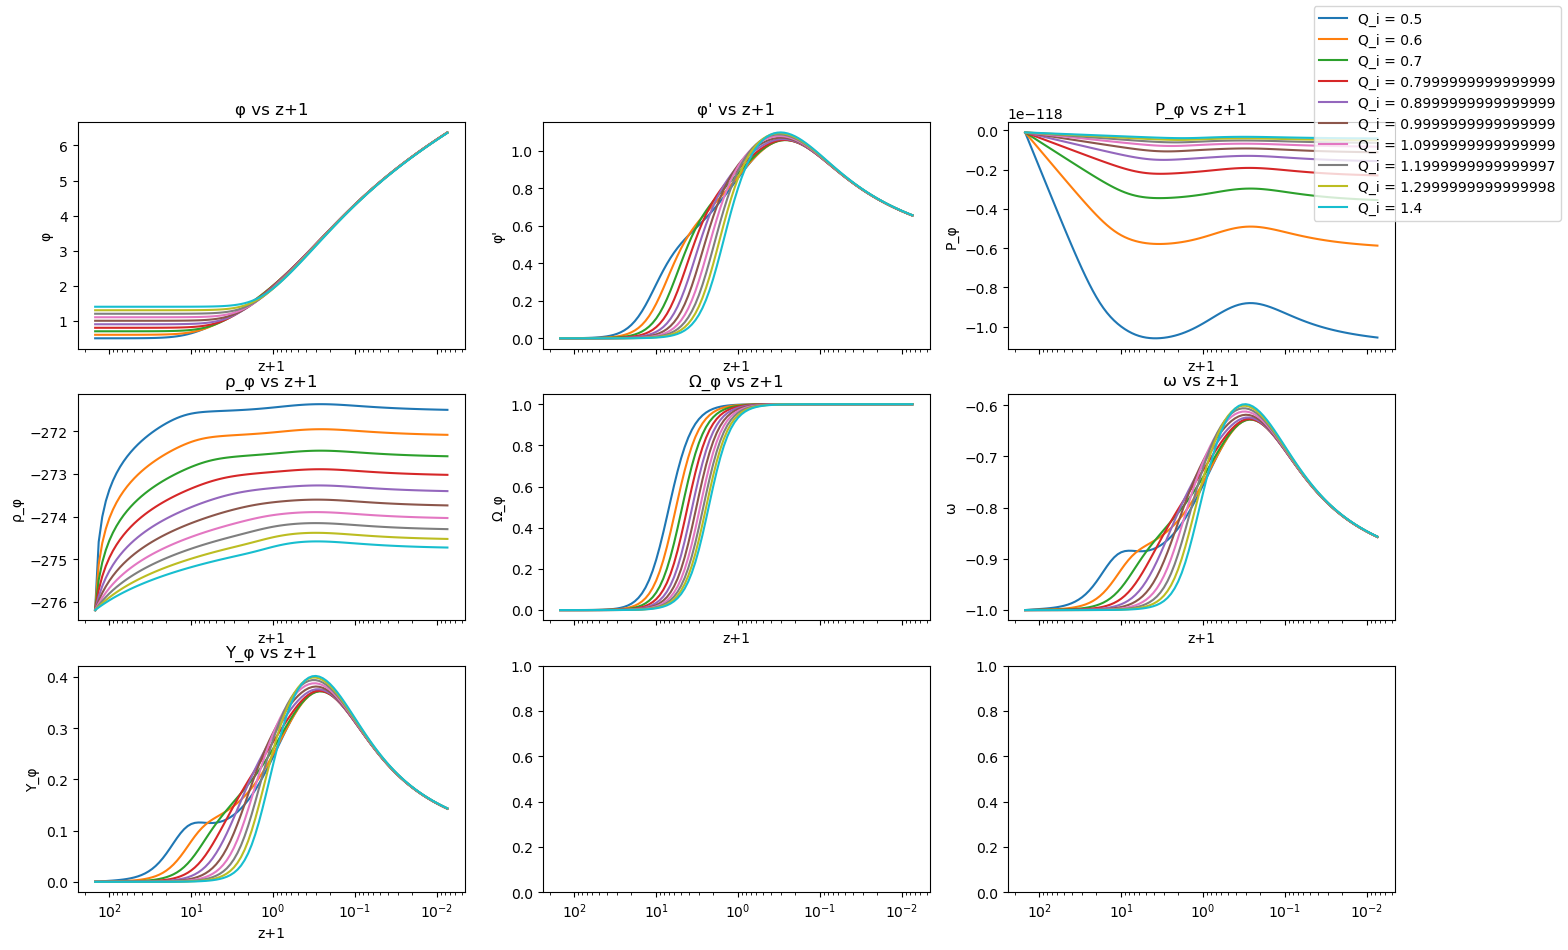

In [30]:
Nrange = np.arange(-5,5,0.1)
Q_values = np.arange(.5,1.5,0.1)
Q_list = []
fig, axs = plt.subplots(3,3, figsize=(17, 10),sharex=True)
def xaxis(x,label,i):
    axs[0,0].set_xscale('log')    
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "{}".format(label),title=r"φ vs {}".format(label))
    if label == "z+1":
        axs[0,0].xaxis.set_inverted(True)
    
    axs[0,1].plot(x,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "{}".format(label),title=r"φ' vs {}".format(label))
    
    axs[0,2].plot(x,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"P_φ vs {}".format(label))
    
    axs[1,0].plot(x,log(rho),label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "{}".format(label),title=r"ρ_φ vs {}".format(label))
    
    axs[1,1].plot(x,om,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "{}".format(label),title=r"Ω_φ vs {}".format(label))
    
    axs[1,2].plot(x,w,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"ω", xlabel = "{}".format(label),title=r"ω vs {}".format(label))

    axs[2,0].plot(x,Y_φ,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"Y_φ", xlabel = "{}".format(label),title=r"Y_φ vs {}".format(label))

for i in Q_values:
    if i ==0:
        continue
    else:
        Q_list.append("Q_i = {}".format(i))
        solQ = odeint(solveSteinhardtKG,[i,0,rho_c0],t=Nrange)
        '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ,x values for all initial Q values ranged. '''
        z,rho,P,om,w,Y_φ,rho_mat = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
        Z = z+1
        xaxis(Z,"z+1",i) # Here is where you can alter whether to view graphs w.r.t to N or z+1

fig.legend(Q_list)

In [61]:
# Gamma:
Gam = var('Γ')
Gam = (V.diff(phi,2))*V/(V.diff(phi))^2
show(Gam)

3/2

In [39]:
# Slow roll parameters: <<1 for inflation
ep = var(r'ε')
ep = 0.5*(V.diff(phi)/V)^2

n = var(r'η')
n = V.diff(phi,2)/V
show(n)

2.00000000000000/φ^2

6/φ^2

In [37]:
# dlnx/dlna:
# N = var('N')
# y =function('y')(N)
# #Y = function(N)
# Y = (ln(y)).diff(N)
# show(Y)

diff(y(N), N)/y(N)